# 9.1 K-means クラスタリング (K-means Clustering)

本ノートブックでは、非教師あり学習の代表的アルゴリズムである **K-means クラスタリング** を学びます。
歪み尺度（コスト関数）$J$ の定式化、座標降下法による2段階の反復最適化、イエローストーン国立公園の **Old Faithful 間欠泉データ** に対するクラスタ形成の反復過程（**PRML Figure 9.1**）と歪み尺度の単調減少（**PRML Figure 9.2**）を完全再現します。
さらに、応用例としてカラー画像の **画像セグメンテーションと色量子化（PRML Figure 9.3）** を実装し、クラスタ数 $K$ による圧縮効果を可視化します。

## 9.1 K-means アルゴリズムと Old Faithful データのクラスタリング (PRML Figure 9.1, 9.2)

### 歪み尺度 (Distortion Measure)
非教師あり学習の代表的なアルゴリズムである K-means は、$N$ 個のデータ点 $\{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ を $K$ 個のクラスタに分割する手法です。各クラスタ $k = 1, \dots, K$ は、その代表点である **プロトタイプベクトル (中心)** $\boldsymbol{\mu}_k$ によって特徴付けられます。

データ点 $\mathbf{x}_n$ がクラスタ $k$ に割り当てられることを表すために、二値の指示変数 (indicator variable) $r_{nk} \in \{0, 1\}$ を導入します。ここで、$r_{nk} = 1$ ならばデータ点 $\mathbf{x}_n$ はクラスタ $k$ に属し、それ以外の場合は $r_{nk} = 0$ となります。各データ点は必ず1つのクラスタに割り当てられるため、$\sum_{k=1}^K r_{nk} = 1$ が成り立ちます。

K-means アルゴリズムの目的関数は、各データ点と、それに割り当てられたクラスタ中心とのユークリッド距離の二乗和として定義されます。この目的関数は **歪み尺度 (distortion measure)** と呼ばれ、次のように定式化されます（PRML 式 9.1）：
$$ J = \sum_{n=1}^N \sum_{k=1}^K r_{nk} \|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2 $$

アルゴリズムの目的は、この目的関数 $J$ を最小化するような割り当て $\{r_{nk}\}$ およびクラスタ中心 $\{\boldsymbol{\mu}_k\}$ を見つけることです。

### 座標降下法 (Coordinate Descent) による反復最適化
$J$ の最小化は、$\{r_{nk}\}$ と $\{\boldsymbol{\mu}_k\}$ の2つの変数集合に関する最適化問題ですが、同時に最適化することは困難です。そこで K-means アルゴリズムは、一方の変数集合を固定して他方を最適化するという操作を交互に繰り返す **座標降下法 (coordinate descent)** を採用します。これは後に学ぶ EM アルゴリズムの特別な場合（ハード EM）とみなすことができます。

#### 1. 割り当てステップ (E-step 相当)
まず、クラスタ中心 $\boldsymbol{\mu}_k$ を固定し、$J$ を最小化するように割り当て変数 $r_{nk}$ を更新します。$J$ は各データ点 $n$ について独立した項の和となっているため、各データ点ごとに別々に最適化を行うことができます。
各点 $\mathbf{x}_n$ について、$\|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2$ を最小にするクラスタ $k$ を選び、その $r_{nk}$ を 1 に、その他を 0 に設定します：
$$ r_{nk} = \begin{cases} 1 & \text{if } k = \arg\min_j \|\mathbf{x}_n - \boldsymbol{\mu}_j\|^2 \\ 0 & \text{otherwise} \end{cases} $$
これにより、空間全体は各クラスタ中心を母点とする **ボロノイ図 (Voronoi tessellation)** によって分割されます。各点は、自分自身が属するボロノイ領域 (Voronoi cell) の中心に割り当てられます。

#### 2. 中心更新ステップ (M-step 相当)
次に、割り当て変数 $r_{nk}$ を固定し、$J$ をクラスタ中心 $\boldsymbol{\mu}_k$ について最小化します。$J$ は $\boldsymbol{\mu}_k$ の二次関数であるため、微分して $0$ とおくことで解析的に解を求めることができます。
$\boldsymbol{\mu}_k$ に関する勾配を計算します：
$$ \frac{\partial J}{\partial \boldsymbol{\mu}_k} = 2 \sum_{n=1}^N r_{nk} (\boldsymbol{\mu}_k - \mathbf{x}_n) = \mathbf{0} $$
これを $\boldsymbol{\mu}_k$ について解くと、クラスタ $k$ に割り当てられたデータ点の平均ベクトル（重心）が得られます：
$$ \boldsymbol{\mu}_k = \frac{\sum_{n=1}^N r_{nk} \mathbf{x}_n}{\sum_{n=1}^N r_{nk}} $$
分母はクラスタ $k$ に割り当てられたデータ点の総数 $N_k = \sum_{n=1}^N r_{nk}$ を表します。

### 収束保証 (Convergence Guarantee)
K-means アルゴリズムの重要な性質は、各ステップ（割り当てステップと中心更新ステップ）において、目的関数 $J$ の値が **必ず単調減少（または不変）** することが保証されている点です。
- 割り当てステップでは、各データ点をより近い（または同じ距離の）クラスタ中心に再割り当てするため、$J$ は減少するか変化しません。
- 中心更新ステップでは、クラスタ中心をそのクラスタに属する点群の重心（二次関数の最小値）に移動させるため、$J$ は減少するか変化しません。

データ点の割り当てパターンは有限個（$K^N$ 通り）しか存在しないため、$J$ の減少はいつか停止します。したがって、K-means アルゴリズムは必ず有限回の反復で収束します。ただし、得られる解は最適解 (global minimum) ではなく、局所最小解 (local minimum) である可能性があります。

### K-means の限界と注意点 (Limitations)
- **ハード割り当て (Hard Assignments):** 各データ点を1つのクラスタに完全に割り当てる（確率的な解釈がない）ため、境界付近の点に対しては割り当てが不安定になることがあります。
- **クラスタ形状の制約:** ユークリッド距離を用いているため、クラスタは球状（等方的なガウス分布を仮定したことと同義）に形成される傾向があります。楕円形や複雑な形状のクラスタには適していません。
- **初期値依存性:** 局所最小解に陥りやすいため、初期化（初期の $\boldsymbol{\mu}_k$ の選び方）によって最終的なクラスタリング結果が大きく変わる（sensitivity to initialization）問題があります。これを緩和するために、K-means++ のような初期化手法が用いられます。

Plot saved to: result/fig9_1_kmeans_faithful_steps.png


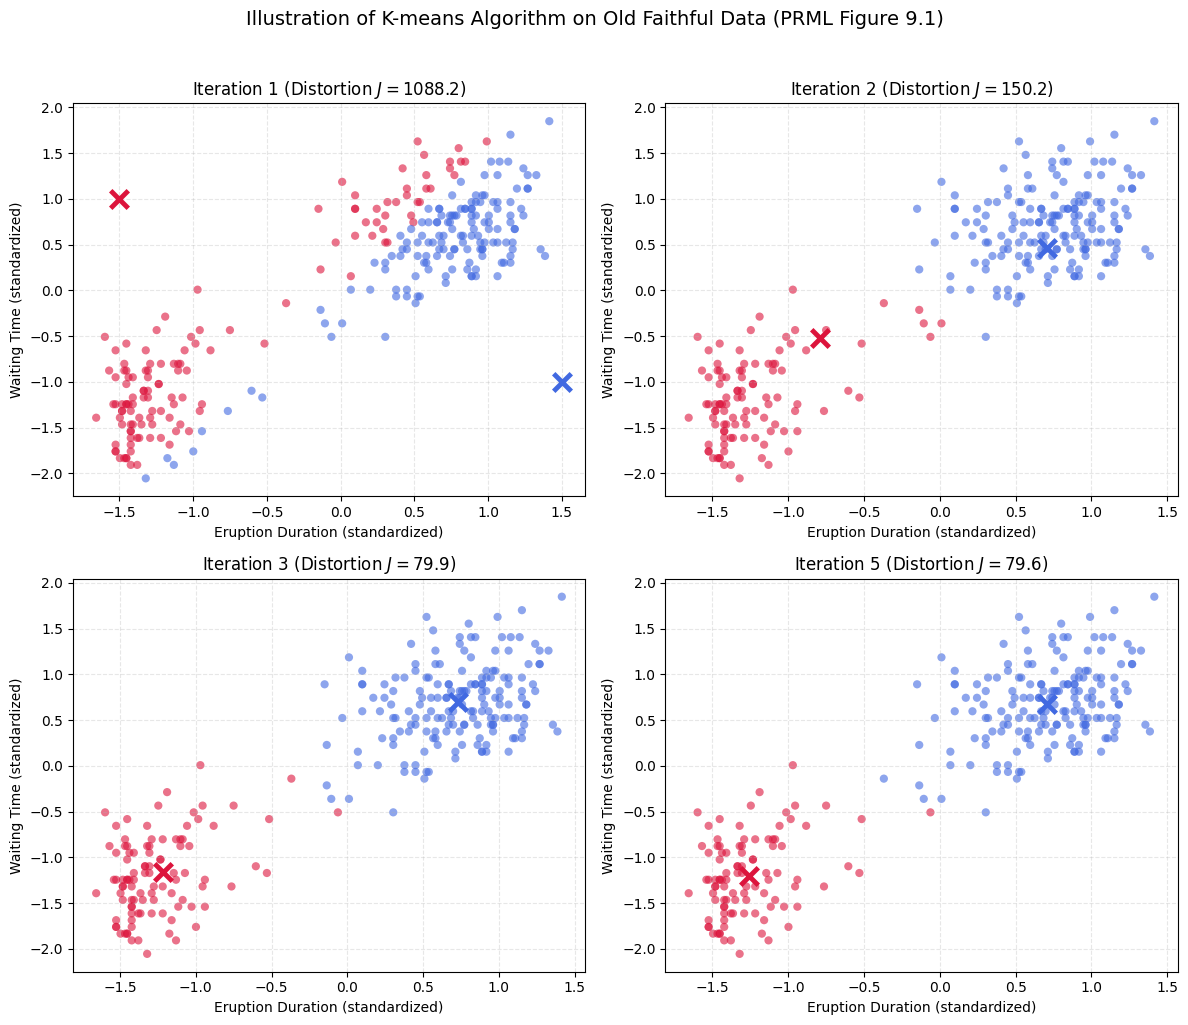

Plot saved to: result/fig9_2_distortion_measure_decrease.png


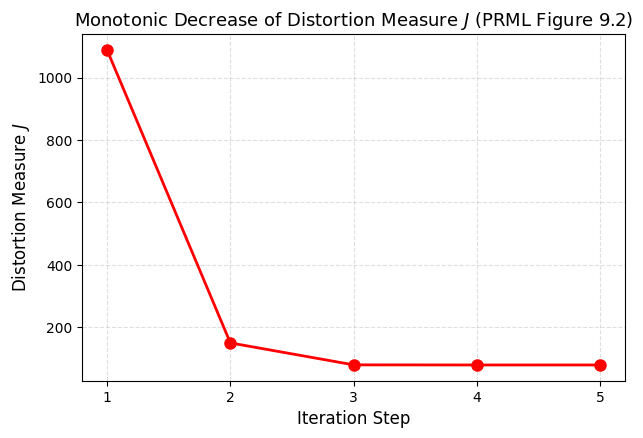

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.mixture_em_utils import KMeans
setup_style()

# Old Faithful データの読み込みと標準化 (PRML 9.1)
df = pd.read_csv('../common/faithful.csv')
X_raw = df[['duration', 'waiting']].values
# 平均0, 標準偏差1にスケーリング
X = (X_raw - np.mean(X_raw, axis=0)) / np.std(X_raw, axis=0)

# PRML Figure 9.1 の初期値設定 (手動初期化による反復過程の忠実な再現)
K = 2
mu_init = np.array([[-1.5, 1.0], [1.5, -1.0]])

# ステップごとの状態を記録
history_centers = [mu_init.copy()]
history_labels = []
cost_history = []

centers = mu_init.copy()
for step in range(5):
    # 割り当て
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist_sq = np.sum(diff**2, axis=-1)
    labels = np.argmin(dist_sq, axis=1)
    cost = np.sum(np.min(dist_sq, axis=1))
    
    history_labels.append(labels.copy())
    cost_history.append(cost)
    
    # 中心更新
    new_centers = np.array([np.mean(X[labels == k], axis=0) for k in range(K)])
    centers = new_centers.copy()
    history_centers.append(centers.copy())

# PRML Figure 9.1 のプロット: 4つの反復ステージ
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

cluster_colors = ['crimson', 'royalblue']
step_indices = [0, 1, 2, 4]

for idx, s in enumerate(step_indices):
    ax = axes[idx]
    lbl = history_labels[s]
    mu_curr = history_centers[s]
    
    # データ点のプロット
    for k in range(K):
        ax.scatter(X[lbl == k, 0], X[lbl == k, 1], c=cluster_colors[k], alpha=0.6, s=35, edgecolors='none')
        # クラスタ中心 (クロスマーカー)
        ax.scatter(mu_curr[k, 0], mu_curr[k, 1], c=cluster_colors[k], marker='x', s=160, lw=3.5, zorder=5)
        
    ax.set_title(f'Iteration {s+1} (Distortion $J={cost_history[s]:.1f}$)', fontsize=12)
    ax.set_xlabel('Eruption Duration (standardized)', fontsize=10)
    ax.set_ylabel('Waiting Time (standardized)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Illustration of K-means Algorithm on Old Faithful Data (PRML Figure 9.1)', fontsize=14, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig9_1_kmeans_faithful_steps.png')
plt.show()

# PRML Figure 9.2 のプロット: 歪み尺度 J の単調減少曲線
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cost_history) + 1), cost_history, 'ro-', lw=2, markersize=8)
ax.set_xlabel('Iteration Step', fontsize=12)
ax.set_ylabel('Distortion Measure $J$', fontsize=12)
ax.set_title('Monotonic Decrease of Distortion Measure $J$ (PRML Figure 9.2)', fontsize=13)
ax.set_xticks(range(1, len(cost_history) + 1))
ax.grid(True, linestyle='--', alpha=0.4)

save_plot(fig, 'result', 'fig9_2_distortion_measure_decrease.png')
plt.show()

## 9.1.1 画像セグメンテーションと色量子化 (PRML Figure 9.3)

各ピクセルのRGBカラー値（3次元ベクトル）をデータ点と見なし、K-means クラスタリングを適用します。
各ピクセルを所属クラスタの中心色 $\boldsymbol{\mu}_k$ に置き換えることで、画像をわずか $K$ 色に色量子化（圧縮）します。
$K=2, 3, 10$ のときの画質と圧縮表現の推移を可視化します。

Plot saved to: result/fig9_3_image_segmentation_kmeans.png


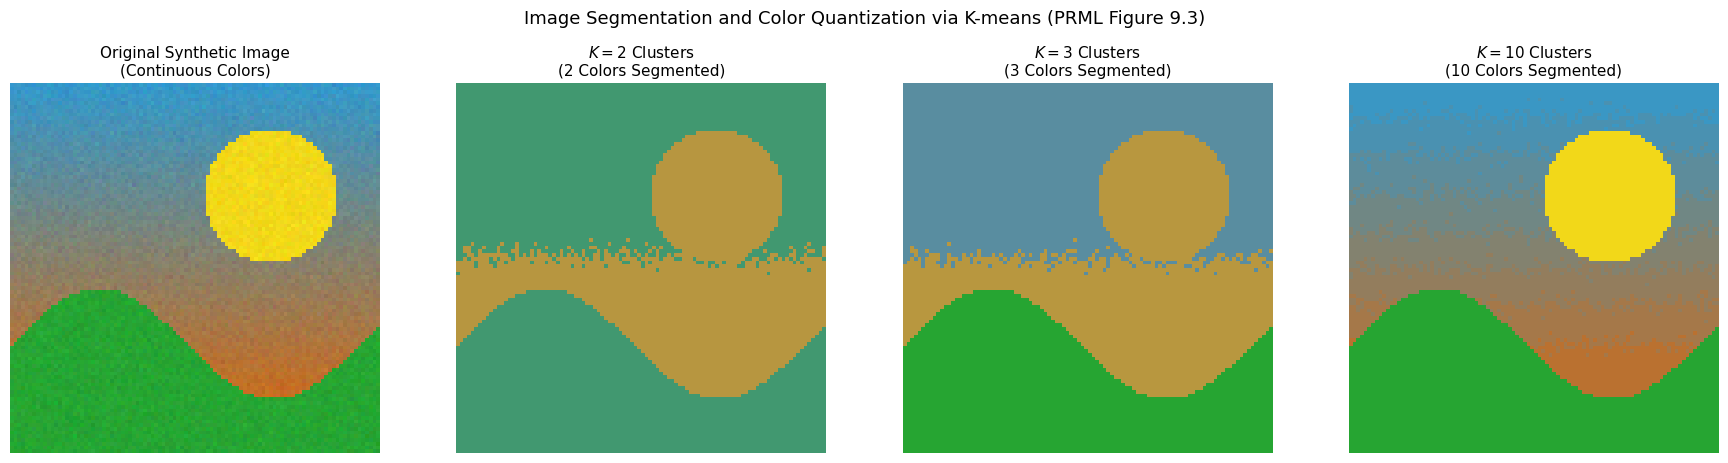

In [2]:
# PRML Figure 9.3: 画像セグメンテーションと色量子化
# 豊かな色彩を持つテストパターンの生成 (グラデーションと幾何学図形)
H, W = 100, 100
np.random.seed(42)
img_rgb = np.zeros((H, W, 3))

# 背景: 空の青から夕焼けのオレンジへのグラデーション
for y in range(H):
    t = y / H
    img_rgb[y, :, 0] = 0.2 + 0.7 * t      # Red
    img_rgb[y, :, 1] = 0.4 + 0.2 * (1-t)  # Green
    img_rgb[y, :, 2] = 0.8 * (1 - t)      # Blue

# 前景: 緑の丘と黄色の太陽
Y, X_grid = np.ogrid[:H, :W]
sun_mask = (X_grid - 70)**2 + (Y - 30)**2 < 18**2
img_rgb[sun_mask] = [0.95, 0.85, 0.1] # 太陽 (Yellow)

hill_mask = Y > (70 - 15 * np.sin(X_grid / 15.0))
img_rgb[hill_mask] = [0.15, 0.65, 0.2] # 丘 (Green)

# ノイズを少し加えて実画像に近づける
img_rgb = np.clip(img_rgb + np.random.normal(0, 0.02, img_rgb.shape), 0.0, 1.0)

# ピクセル配列の展開 (H*W, 3)
pixels = img_rgb.reshape(-1, 3)

# K = 2, 3, 10 によるセグメンテーション
K_values = [2, 3, 10]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Synthetic Image\n(Continuous Colors)', fontsize=11)
axes[0].axis('off')

for i, K_val in enumerate(K_values):
    km = KMeans(n_clusters=K_val, max_iter=30, random_state=42)
    km.fit(pixels)
    # 各ピクセルをクラスタ中心の色に置換
    quantized_pixels = km.cluster_centers_[km.labels_]
    quantized_img = quantized_pixels.reshape(H, W, 3)
    
    axes[i+1].imshow(quantized_img)
    axes[i+1].set_title(f'$K = {K_val}$ Clusters\n({K_val} Colors Segmented)', fontsize=11)
    axes[i+1].axis('off')

plt.suptitle('Image Segmentation and Color Quantization via K-means (PRML Figure 9.3)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig9_3_image_segmentation_kmeans.png')
plt.show()